In [2]:
import os

In [3]:
import pycisTopic
pycisTopic.__version__

'2.0a0'

In [16]:
#!mkdir -p data
#!wget -O data/fragments.tsv.gz https://cf.10xgenomics.com/samples/cell-arc/1.0.0/human_brain_3k/human_brain_3k_atac_fragments.tsv.gz
#!wget -O data/fragments.tsv.gz.tbi https://cf.10xgenomics.com/samples/cell-arc/1.0.0/human_brain_3k/human_brain_3k_atac_fragments.tsv.gz.tbi
#!wget -O data/cell_data.tsv https://raw.githubusercontent.com/aertslab/pycisTopic/polars/data/cell_data_human_cerebellum.tsv

In [4]:
data_dir = "/.mounts/labs/pailab/private/spai/data/SCENICp/data"
out_dir = "outs"
os.makedirs(out_dir, exist_ok = True)

In [5]:
fragments_dict = {
    "10x_multiome_brain": os.path.join(data_dir,"fragments.tsv.gz")
}

In [6]:
import pandas as pd
cell_file = os.path.join(data_dir,"cell_data.tsv")
cell_data = pd.read_table(cell_file,index_col=0)
cell_data.head()

,VSN_cell_type,VSN_leiden_res0.3,VSN_leiden_res0.6,VSN_leiden_res0.9,VSN_leiden_res1.2,VSN_sample_id,Seurat_leiden_res0.6,Seurat_leiden_res1.2,Seurat_cell_type
AAACAGCCATTATGCG-1-10x_multiome_brain,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_1 (1),MOL_B_3 (6),10x_multiome_brain,NFOL (1),MOL (1),MOL
AAACCAACATAGACCC-1-10x_multiome_brain,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_3 (5),MOL_B_4 (4),10x_multiome_brain,NFOL (1),NFOL (3),NFOL
AAACCGAAGATGCCTG-1-10x_multiome_brain,INH_VIP,INH_VIP (6),INH_VIP (8),INH_VIP (8),INH_VIP (10),10x_multiome_brain,INH_VIP (7),INH_VIP (6),INH_VIP
AAACCGAAGTTAGCTA-1-10x_multiome_brain,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_2 (0),10x_multiome_brain,NFOL (1),NFOL (3),NFOL
AAACCGCGTTAGCCAA-1-10x_multiome_brain,MGL,MGL (7),MGL (10),MGL (10),MGL (12),10x_multiome_brain,MGL (8),MGL (9),MGL


Now read chrom sizes.

In [6]:
chrom_file = os.path.join(data_dir, "hg38.chrom.sizes") 
chromsizes = pd.read_table( chrom_file, header = None, names = ["Chromosome", "End"] ) 
chromsizes.insert(1, "Start", 0)
chromsizes.head()

,Chromosome,Start,End
0,chr1,0,248956422
1,chr2,0,242193529
2,chr3,0,198295559
3,chr4,0,190214555
4,chr5,0,181538259


Now we a ready to generate pseudobulk ATAC-seq profiles.

This function will generate a fragments.tsv.gz and a bigwig file for each cell type defined by the variable parameter.

For each cell type:

The fragments.tsv.gz contains all fragments for barcodes of that cell type.

A bigwig file will be generated for each fragments.tsv.gz file, this you can visualize in any genome browser.

In [7]:
%%time
from pycisTopic.pseudobulk_peak_calling import export_pseudobulk
os.makedirs(os.path.join(out_dir, "consensus_peak_calling"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bed_files"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bw_files"), exist_ok = True)


bw_paths, bed_paths = export_pseudobulk(
    input_data = cell_data,
    variable = "VSN_cell_type",
    sample_id_col = "VSN_sample_id",
    chromsizes = chromsizes,
    bed_path = os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bed_files"),
    bigwig_path = os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bw_files"),
    path_to_fragments = fragments_dict,
    n_cpu = 10,
    normalize_bigwig = True,
    temp_dir = "/tmp",
    split_pattern = "-"
)

2025-05-30 12:23:37,569 cisTopic     INFO     Splitting fragments by cell type.
2025-05-30 12:30:01,069 cisTopic     INFO     generating bigwig files


/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CPU times: user 3.83 s, sys: 3.49 s, total: 7.32 s
Wall time: 10min 57s


We will need the paths to the bed files later on, so let’s save them to disk.

In [8]:

bw_paths

{'MOL_B': 'outs/consensus_peak_calling/pseudobulk_bw_files/MOL_B.bw',
 'INH_VIP': 'outs/consensus_peak_calling/pseudobulk_bw_files/INH_VIP.bw',
 'MOL_A': 'outs/consensus_peak_calling/pseudobulk_bw_files/MOL_A.bw',
 'MGL': 'outs/consensus_peak_calling/pseudobulk_bw_files/MGL.bw',
 'PURK': 'outs/consensus_peak_calling/pseudobulk_bw_files/PURK.bw',
 'OPC': 'outs/consensus_peak_calling/pseudobulk_bw_files/OPC.bw',
 'AST_CER': 'outs/consensus_peak_calling/pseudobulk_bw_files/AST_CER.bw',
 'ASTP': 'outs/consensus_peak_calling/pseudobulk_bw_files/ASTP.bw',
 'GC': 'outs/consensus_peak_calling/pseudobulk_bw_files/GC.bw',
 'INH_PVALB': 'outs/consensus_peak_calling/pseudobulk_bw_files/INH_PVALB.bw',
 'INH_SST': 'outs/consensus_peak_calling/pseudobulk_bw_files/INH_SST.bw',
 'AST': 'outs/consensus_peak_calling/pseudobulk_bw_files/AST.bw',
 'GP': 'outs/consensus_peak_calling/pseudobulk_bw_files/GP.bw',
 'ENDO': 'outs/consensus_peak_calling/pseudobulk_bw_files/ENDO.bw'}

In [9]:
with open(os.path.join(out_dir, "consensus_peak_calling/bw_paths.tsv"), "wt") as f:
    for v in bw_paths:
        _ = f.write(f"{v}\t{bw_paths[v]}\n")

In [10]:
bed_paths

{'MOL_B': 'outs/consensus_peak_calling/pseudobulk_bed_files/MOL_B.fragments.tsv.gz',
 'INH_VIP': 'outs/consensus_peak_calling/pseudobulk_bed_files/INH_VIP.fragments.tsv.gz',
 'MOL_A': 'outs/consensus_peak_calling/pseudobulk_bed_files/MOL_A.fragments.tsv.gz',
 'MGL': 'outs/consensus_peak_calling/pseudobulk_bed_files/MGL.fragments.tsv.gz',
 'PURK': 'outs/consensus_peak_calling/pseudobulk_bed_files/PURK.fragments.tsv.gz',
 'OPC': 'outs/consensus_peak_calling/pseudobulk_bed_files/OPC.fragments.tsv.gz',
 'AST_CER': 'outs/consensus_peak_calling/pseudobulk_bed_files/AST_CER.fragments.tsv.gz',
 'ASTP': 'outs/consensus_peak_calling/pseudobulk_bed_files/ASTP.fragments.tsv.gz',
 'GC': 'outs/consensus_peak_calling/pseudobulk_bed_files/GC.fragments.tsv.gz',
 'INH_PVALB': 'outs/consensus_peak_calling/pseudobulk_bed_files/INH_PVALB.fragments.tsv.gz',
 'INH_SST': 'outs/consensus_peak_calling/pseudobulk_bed_files/INH_SST.fragments.tsv.gz',
 'AST': 'outs/consensus_peak_calling/pseudobulk_bed_files/AST.f

In [11]:
with open(os.path.join(out_dir, "consensus_peak_calling/bed_paths.tsv"), "wt") as f:
    for v in bed_paths:
        _ = f.write(f"{v}\t{bed_paths[v]}\n")

## Inferring consensus peaks

Next we will use MACS to call peaks for each pseudobulk fragments.tsv.gz file.


In [12]:
bw_paths = {}
with open(os.path.join(out_dir, "consensus_peak_calling/bw_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bw_paths.update({v: p})

In [13]:
bed_paths = {}
with open(os.path.join(out_dir, "consensus_peak_calling/bed_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bed_paths.update({v: p})

In [14]:
%%time
from pycisTopic.pseudobulk_peak_calling import peak_calling
macs_path = "macs2"

os.makedirs(os.path.join(out_dir, "consensus_peak_calling/MACS"), exist_ok = True)

narrow_peak_dict = peak_calling(
    macs_path = macs_path,
    bed_paths = bed_paths,
    outdir = os.path.join(os.path.join(out_dir, "consensus_peak_calling/MACS")),
    genome_size = 'hs',
    n_cpu = 10,
    input_format = 'BEDPE',
    shift = 73,
    ext_size = 146,
    keep_dup = 'all',
    q_value = 0.05
)

2025-05-30 13:05:31,181	INFO worker.py:1724 -- Started a local Ray instance.


(macs_call_peak_ray pid=1958723) 2025-05-30 13:05:38,677 cisTopic     INFO     Calling peaks for MOL_B with macs2 callpeak --treatment outs/consensus_peak_calling/pseudobulk_bed_files/MOL_B.fragments.tsv.gz --name MOL_B  --outdir outs/consensus_peak_calling/MACS --format BEDPE --gsize hs --qvalue 0.05 --nomodel --shift 73 --extsize 146 --keep-dup all --call-summits --nolambda
(macs_call_peak_ray pid=1958714) 2025-05-30 13:05:38,672 cisTopic     INFO     Calling peaks for AST_CER with macs2 callpeak --treatment outs/consensus_peak_calling/pseudobulk_bed_files/AST_CER.fragments.tsv.gz --name AST_CER  --outdir outs/consensus_peak_calling/MACS --format BEDPE --gsize hs --qvalue 0.05 --nomodel --shift 73 --extsize 146 --keep-dup all --call-summits --nolambda
(macs_call_peak_ray pid=1958718) 2025-05-30 13:05:38,672 cisTopic     INFO     Calling peaks for MOL_A with macs2 callpeak --treatment outs/consensus_peak_calling/pseudobulk_bed_files/MOL_A.fragments.tsv.gz --name MOL_A  --outdir outs/c

Finally, it is time to derive the consensus peaks. To do so, we use the TGCA iterative peak filtering approach. First, each summit is extended a `peak_half_width` in each direction and then we iteratively filter out less significant peaks that overlap with a more significant one. During this procedure peaks will be merged and depending on the number of peaks included into them, different processes will happen:

* 1 peak: The original peak region will be kept
* 2 peaks: The original peak region with the highest score will be kept
* 3 or more peaks: The orignal peak region with the most significant score will be taken, and all the original peak regions in this merged peak region that overlap with the significant peak region will be removed. The process is repeated with the next most significant peak (if it was not removed already) until all peaks are processed.

This proccess will happen twice, first for each pseudobulk peaks; and after peak score normalization, to process all peaks together.

In [15]:
%%time
from pycisTopic.iterative_peak_calling import get_consensus_peaks
# Other param
peak_half_width=250
path_to_blacklist=os.path.join(data_dir,"hg38-blacklist.v2.bed")
# Get consensus peaks
consensus_peaks = get_consensus_peaks(
    narrow_peaks_dict = narrow_peak_dict,
    peak_half_width = peak_half_width,
    chromsizes = chromsizes,
    path_to_blacklist = path_to_blacklist)

2025-05-30 13:12:17,390 cisTopic     INFO     Extending and merging peaks per class
2025-05-30 13:13:50,728 cisTopic     INFO     Normalizing peak scores
2025-05-30 13:13:51,409 cisTopic     INFO     Merging peaks
Warning! Start and End columns now have different dtypes: int64 and int32
2025-05-30 13:15:47,994 cisTopic     INFO     Done!
CPU times: user 3min 25s, sys: 2.89 s, total: 3min 28s
Wall time: 3min 30s


In [34]:
consensus_peaks.to_bed(
    path = os.path.join(out_dir, "consensus_peak_calling/consensus_regions.bed"),
    keep =True,
    compression = 'infer',
    chain = False)

/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis

## QC
The next step is to perform QC for the scATAC-seq samples (in this case, only one run). There are several measurements and visualizations performed in this step:

* Barcode rank plot
* Duplication rate
* Insertion size
* TSS enrichment
* Fraction of Reads In Peaks (FRIP)

To calculate the TSS enrichment we need to provide TSS annotations. You can easily download them via the `pycistopic tss get_tss` command.

In case you are unsure which column name is used by Ensembl to specify gene names in their databases, run the `pycistopic tss gene_annotation_list` and grep for your species.

In [35]:
# Commented out this line because HPC doesn't connect to internet & Ensembl is too slow.
#
#!pycistopic tss get_tss \
#    --output outs/qc/tss.bed \
#    --name "hsapiens_gene_ensembl" \
#    --to-chrom-source ucsc \
#    --ucsc hg38

Traceback (most recent call last):
  File "/u/spai/.conda/envs/scenicplus/bin/pycistopic", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/cli/pycistopic.py", line 26, in main
    args.func(args)
  File "/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/cli/subcommand/tss.py", line 479, in run_tss_gene_annotation_list
    get_species_gene_annotation_ensembl_biomart_dataset_names(
  File "/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/cli/subcommand/tss.py", line 299, in get_species_gene_annotation_ensembl_biomart_dataset_names
    biomart_datasets = ga.get_all_gene_annotation_ensembl_biomart_dataset_names(
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/gene_annotation.py", line 59, in get_all_gene_annotation_ensembl_biomart_dataset_names
  

In [23]:
!head tss.bed | column -t

Chromosome  Start   End     Gene        Score  Strand  Transcript_type
chr1        69091   70008   OR4F5       .      +       protein_coding
chr1        134901  139379  AL627309.1  .      -       protein_coding
chr1        367640  368634  OR4F29      .      +       protein_coding
chr1        621059  622053  OR4F16      .      -       protein_coding
chr1        738532  739137  AL669831.1  .      -       protein_coding
chr1        818043  819983  AL645608.2  .      +       protein_coding
chr1        860260  879955  SAMD11      .      +       protein_coding
chr1        861264  866445  AL645608.1  .      -       protein_coding
chr1        879584  894689  NOC2L       .      -       protein_coding


In [30]:
!mkdir -p outs/qc
!pycistopic qc \
    --fragments /.mounts/labs/pailab/private/spai/data/SCENICp/data/fragments.tsv.gz \
    --regions outs/consensus_peak_calling/consensus_regions.bed \
    --tss tss.bed \
    --output outs/qc/10x_multiome_brain

Next, let’s calculate the QC metrics using the pycistopic qc command.

Now let's plot

In [31]:
from pycisTopic.plotting.qc_plot import plot_sample_stats, plot_barcode_stats
import matplotlib.pyplot as plt

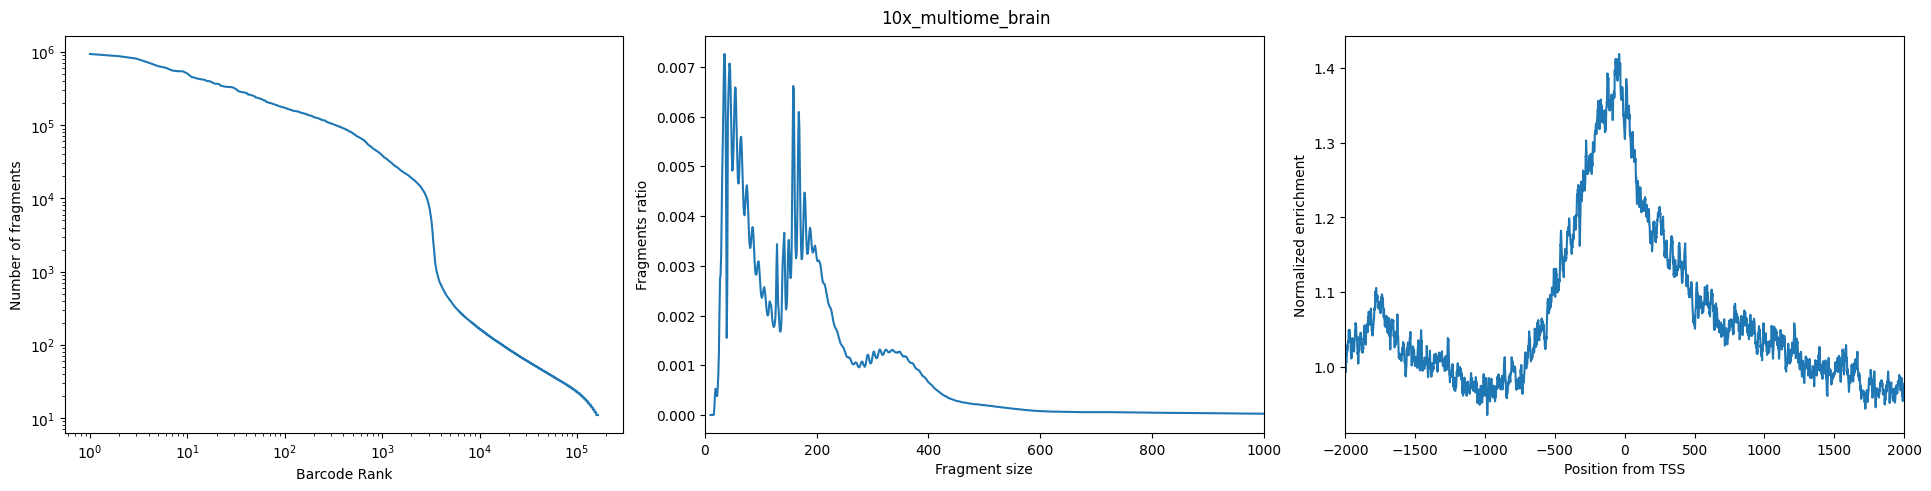

In [32]:
for sample_id in fragments_dict:
    fig = plot_sample_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = "outs/qc"
    )

In [34]:
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
for sample_id in fragments_dict:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir = "outs/qc",
            unique_fragments_threshold = None, # use automatic thresholding
            tss_enrichment_threshold = None, # use automatic thresholding
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

10x_multiome_brain:
	Using automatic threshold for unique fragments: 1500.1880245466896
	Using automatic threshold for TSS enrichment: 1.5171133901852512


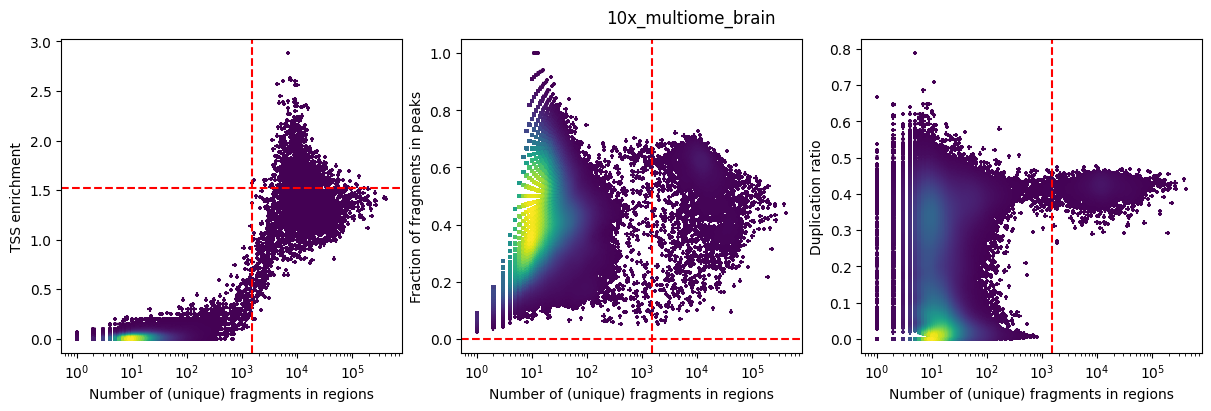

In [35]:
for sample_id in fragments_dict:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = "outs/qc",
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,
        **sample_id_to_thresholds[sample_id]
    )

In [18]:
##Creating a cisTopic object
In this step we will create a cisTopic object. This involves generating a count matrix containing fragment counts over consensus peaks (see above) for each cell barcode passing the QC metrices defined above.

Blacklist regions will be removed from this count matrix.

In [37]:
path_to_regions = os.path.join(out_dir, "consensus_peak_calling/consensus_regions.bed")
path_to_blacklist = os.path.join(data_dir,"hg38-blacklist.v2.bed")
pycistopic_qc_output_dir = "outs/qc"

from pycisTopic.cistopic_class import create_cistopic_object_from_fragments
import polars as pl

cistopic_obj_list = []
for sample_id in fragments_dict:
    sample_metrics = pl.read_parquet(
        os.path.join(pycistopic_qc_output_dir, f'{sample_id}.fragments_stats_per_cb.parquet')
    ).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample_id] ]
    cistopic_obj = create_cistopic_object_from_fragments(
        path_to_fragments = fragments_dict[sample_id],
        path_to_regions = path_to_regions,
        path_to_blacklist = path_to_blacklist,
        metrics = sample_metrics,
        valid_bc = sample_id_to_barcodes_passing_filters[sample_id],
        n_cpu = 1,
        project = sample_id,
        split_pattern = '-'
    )
    cistopic_obj_list.append(cistopic_obj)

2025-05-30 14:03:53,952 cisTopic     INFO     Reading data for 10x_multiome_brain
2025-05-30 14:06:39,187 cisTopic     INFO     metrics provided!
2025-05-30 14:06:44,961 cisTopic     INFO     Counting fragments in regions
2025-05-30 14:07:00,164 cisTopic     INFO     Creating fragment matrix
2025-05-30 14:07:13,964 cisTopic     INFO     Converting fragment matrix to sparse matrix
2025-05-30 14:07:16,600 cisTopic     INFO     Removing blacklisted regions
2025-05-30 14:07:18,314 cisTopic     INFO     Creating CistopicObject
2025-05-30 14:07:19,434 cisTopic     INFO     Done!


In this case we only have one sample, so only one cisTopic object has been generated. If you would have multiple samples, you would need to run the merge() function on your cisTopic object list.

In [38]:
cistopic_obj = cistopic_obj_list[0]
print(cistopic_obj)

CistopicObject from project 10x_multiome_brain with n_cells × n_regions = 957 × 428526


In [39]:
import pickle
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

## Adding metadata to a CisTopic object
We can add additional metadata (for regions or cells) to a cisTopic object. For example, let’s add the scRNA-seq data annotations. Missing values will be filled with Nan.



In [8]:
print(out_dir)

outs


In [13]:
import pickle
cisobj_file=os.path.join(out_dir,"cistopic_obj.pkl")

with open(cisobj_file, 'rb') as pickle_file:
    cistopic_obj = pickle.load(pickle_file)

In [40]:
import pandas as pd
cell_data = pd.read_table(os.path.join(data_dir,"cell_data.tsv"), index_col = 0)
cell_data.head()
cistopic_obj.add_cell_data(cell_data, split_pattern='-')
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

In [14]:
cistopic_obj.cell_data


,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,barcode,VSN_cell_type,VSN_leiden_res0.3,VSN_leiden_res0.6,VSN_leiden_res0.9,VSN_leiden_res1.2,VSN_sample_id,Seurat_leiden_res0.6,Seurat_leiden_res1.2,Seurat_cell_type
GTTTACCGTTAGCTGA-1-10x_multiome_brain,5420,3.733999,4899,3.690107,10x_multiome_brain,2727,19904,4.298962,11817,4.072544,...,GTTTACCGTTAGCTGA-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GACCTAAGTTTGGCGG-1-10x_multiome_brain,15260,4.183555,13239,4.121855,10x_multiome_brain,1578,37266,4.571324,23805,4.376686,...,GACCTAAGTTTGGCGG-1,AST_CER,AST_CER (2),AST_CER (2),AST_CER (2),AST_CER_1 (7),10x_multiome_brain,BG (2),BG (2),BG
CTTGTAAAGGTACCGC-1-10x_multiome_brain,44493,4.648292,34938,4.543298,10x_multiome_brain,460,138293,5.140803,82339,4.915611,...,CTTGTAAAGGTACCGC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GCTATTGCAACACCTA-1-10x_multiome_brain,10803,4.033544,9535,3.979321,10x_multiome_brain,2408,26657,4.425828,15174,4.181129,...,GCTATTGCAACACCTA-1,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_2 (0),10x_multiome_brain,MOL (0),MOL (0),MOL
ACATTGCAGTAGCCAT-1-10x_multiome_brain,12376,4.09258,10626,4.02637,10x_multiome_brain,2106,31805,4.502509,17951,4.254113,...,ACATTGCAGTAGCCAT-1,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_2 (0),10x_multiome_brain,MOL (0),MOL (0),MOL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAGTAACCAGTAGCCT-1-10x_multiome_brain,8478,3.928293,7584,3.879898,10x_multiome_brain,2683,20398,4.309609,12305,4.090117,...,GAGTAACCAGTAGCCT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GAGTAACCAGCAAGAT-1-10x_multiome_brain,6013,3.779091,5440,3.735599,10x_multiome_brain,2901,17405,4.240699,9777,3.990250,...,GAGTAACCAGCAAGAT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TACTGGCCACCGGTAT-1-10x_multiome_brain,5053,3.703549,4662,3.668572,10x_multiome_brain,3070,12751,4.105578,7285,3.862489,...,TACTGGCCACCGGTAT-1,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_2 (0),10x_multiome_brain,MOL (0),MOL (0),MOL
GGCTCACAGGCCCAGT-1-10x_multiome_brain,6191,3.791761,5724,3.7577,10x_multiome_brain,2184,26566,4.424343,17298,4.238021,...,GGCTCACAGGCCCAGT-1,INH_VIP,INH_VIP (6),INH_VIP (8),INH_VIP (8),INH_VIP (10),10x_multiome_brain,INH_VIP (7),INH_VIP (6),INH_VIP


## Run Models

In [ ]:
Next we will perform the actual topic modeling using LDA using a Collapsed Gibbs Sampler.

There are two functions that ca be used to perform the topic modeling, both producde similar results.

Serial LDA: The parallelization is done between models rather than within each model. Recommended for small-medium sized data sets in which several models with different number of topics are being tested. You can run these models with runCGSModels().

Parallel LDA with MALLET: The parallelization is done within each model. Recommended for large data sets where a few models with different number of topics are being tested. If working in a cluster, we recommed to submit a job per model so they can run simultaneously. You can run it with runCGSModelsMallet().

Here, we will use Mallet.

In [42]:
!mkdir -p /scratch2/users/spai/mallet/tutorial

In [ ]:
Because we don’t know yet what number of topics will be optimal for our dataset we will run several topic models, each with a different number of topics.



In [1]:
!java -version

java version "17.0.3.1" 2022-04-22 LTS
Java(TM) SE Runtime Environment (build 17.0.3.1+2-LTS-6)
Java HotSpot(TM) 64-Bit Server VM (build 17.0.3.1+2-LTS-6, mixed mode, sharing)


In [15]:
%%time
os.environ['MALLET_MEMORY'] = '200G'
from pycisTopic.lda_models import run_cgs_models_mallet
# Configure path Mallet
mallet_path="/u/spai/software/Mallet-202108/bin/mallet"
# Run models
models=run_cgs_models_mallet(
    cistopic_obj,
    n_topics=[2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    n_cpu=12,
    n_iter=500,
    random_state=555,
    alpha=50,
    alpha_by_topic=True,
    eta=0.1,
    eta_by_topic=False,
    tmp_path="/scratch2/users/spai/mallet/tutorial",
    save_path="/scratch2/users/spai/mallet/tutorial",
    mallet_path=mallet_path,
)

2025-05-30 14:37:56,294 cisTopic     INFO     Formatting input to corpus
2025-05-30 14:37:56,735 cisTopic     INFO     Running model with 2 topics
2025-05-30 14:37:56,754 LDAMalletWrapper INFO     Serializing temporary corpus to /scratch2/users/spai/mallet/tutorial/corpus.txt
2025-05-30 14:38:08,888 LDAMalletWrapper INFO     Converting temporary corpus to MALLET format with: /u/spai/software/Mallet-202108/bin/mallet import-file --preserve-case --keep-sequence --token-regex \S+ --input /scratch2/users/spai/mallet/tutorial/corpus.txt --output /scratch2/users/spai/mallet/tutorial/corpus.mallet
2025-05-30 14:38:33,981 LDAMalletWrapper INFO     Training MALLET LDA with: /u/spai/software/Mallet-202108/bin/mallet train-topics --input /scratch2/users/spai/mallet/tutorial/corpus.mallet --num-topics 2 --alpha 50 --beta 0.1 --optimize-interval 0 --num-threads 12 --output-state /scratch2/users/spai/mallet/tutorial/7a324e_state.mallet.gz --output-doc-topics /scratch2/users/spai/mallet/tutorial/7a32

In [16]:
pickle.dump(
    models,
    open(os.path.join(out_dir, "models.pkl"), "wb")
)

## Model Selection
For scATAC-seq data models, the most helpful methods are Minmo (topic coherence) and the log-likelihood in the last iteration.

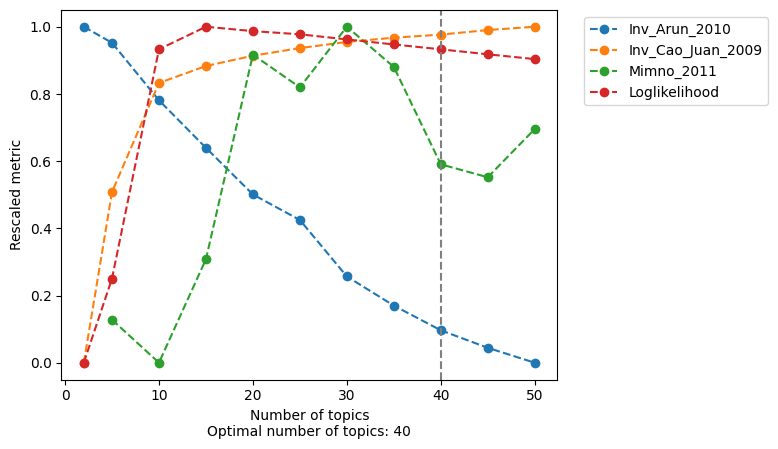

In [17]:
from pycisTopic.lda_models import evaluate_models
model = evaluate_models(
    models,
    select_model = 40,
    return_model = True
)

In [18]:
cistopic_obj.add_LDA_model(model)

In [19]:
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

In [ ]:
## Clustering and visualization
We can cluster the cells (or regions) using the leiden algorithm, and perform dimensionality reductiion with UMAP and TSNE. In these examples we will focus on the cells only. For these steps, the cell-topic contributions of the model will be used.


In [20]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [21]:
%%time
find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [0.6, 1.2, 3],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '-'
)

2025-05-30 16:36:10,290 cisTopic     INFO     Finding neighbours


In [22]:
run_umap(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-05-30 16:38:22,852 cisTopic     INFO     Running UMAP


/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [23]:
run_tsne(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-05-30 16:46:40,428 cisTopic     INFO     Running TSNE


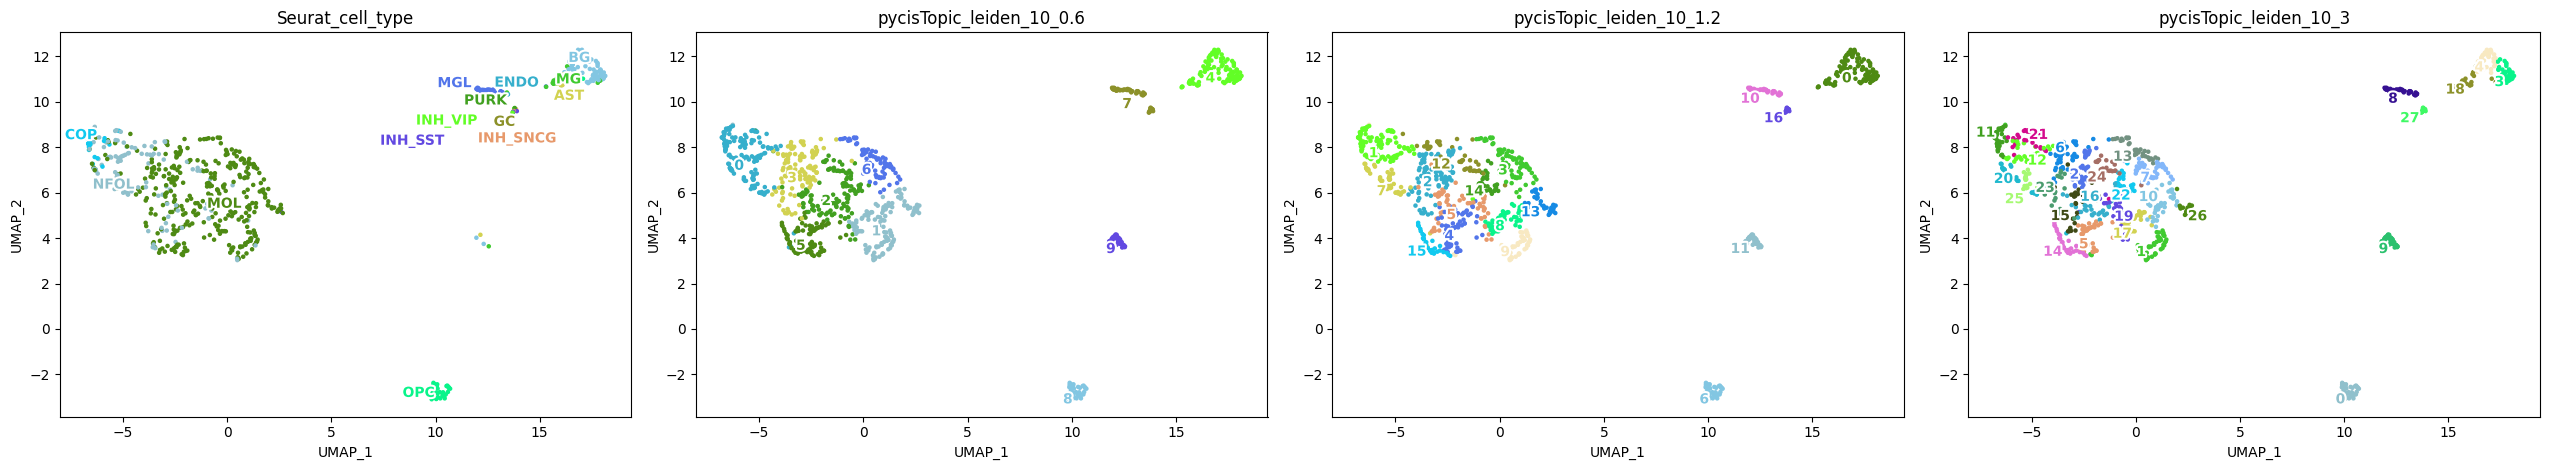

In [24]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['Seurat_cell_type', 'pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

Let’s annotate each cluster based on the overlap with scRNA-seq annotations.

In [25]:
annot_dict = {}
for resolution in [0.6, 1.2, 3]:
    annot_dict[f"pycisTopic_leiden_10_{resolution}"] = {}
    for cluster in set(cistopic_obj.cell_data[f"pycisTopic_leiden_10_{resolution}"]):
        counts = cistopic_obj.cell_data.loc[
            cistopic_obj.cell_data.loc[cistopic_obj.cell_data[f"pycisTopic_leiden_10_{resolution}"] == cluster].index,
            "Seurat_cell_type"].value_counts()
        annot_dict[f"pycisTopic_leiden_10_{resolution}"][cluster] = f"{counts.index[counts.argmax()]}({cluster})"

In [26]:
annot_dict


{'pycisTopic_leiden_10_0.6': {'4': 'BG(4)',
  '7': 'MGL(7)',
  '6': 'MOL(6)',
  '2': 'MOL(2)',
  '0': 'NFOL(0)',
  '5': 'MOL(5)',
  '8': 'OPC(8)',
  '3': 'MOL(3)',
  '9': 'BG(9)',
  '1': 'MOL(1)'},
 'pycisTopic_leiden_10_1.2': {'1': 'NFOL(1)',
  '12': 'MOL(12)',
  '4': 'MOL(4)',
  '14': 'MOL(14)',
  '2': 'MOL(2)',
  '0': 'BG(0)',
  '6': 'OPC(6)',
  '7': 'NFOL(7)',
  '16': 'INH_SST(16)',
  '11': 'BG(11)',
  '5': 'MOL(5)',
  '8': 'MOL(8)',
  '3': 'MOL(3)',
  '15': 'MOL(15)',
  '9': 'MOL(9)',
  '10': 'MGL(10)',
  '13': 'MOL(13)'},
 'pycisTopic_leiden_10_3': {'12': 'NFOL(12)',
  '18': 'MG(18)',
  '2': 'MOL(2)',
  '11': 'COP(11)',
  '16': 'MOL(16)',
  '26': 'MOL(26)',
  '10': 'MOL(10)',
  '17': 'MOL(17)',
  '19': 'MOL(19)',
  '0': 'OPC(0)',
  '5': 'MOL(5)',
  '3': 'BG(3)',
  '1': 'MOL(1)',
  '22': 'MOL(22)',
  '4': 'BG(4)',
  '14': 'MOL(14)',
  '6': 'MOL(6)',
  '8': 'MGL(8)',
  '27': 'INH_SST(27)',
  '9': 'BG(9)',
  '25': 'NFOL(25)',
  '21': 'NFOL(21)',
  '7': 'MOL(7)',
  '24': 'MOL(24)',
 

In [27]:
for resolution in [0.6, 1.2, 3]:
    cistopic_obj.cell_data[f'pycisTopic_leiden_10_{resolution}'] = [
        annot_dict[f'pycisTopic_leiden_10_{resolution}'][x] for x in cistopic_obj.cell_data[f'pycisTopic_leiden_10_{resolution}'].tolist()
    ]

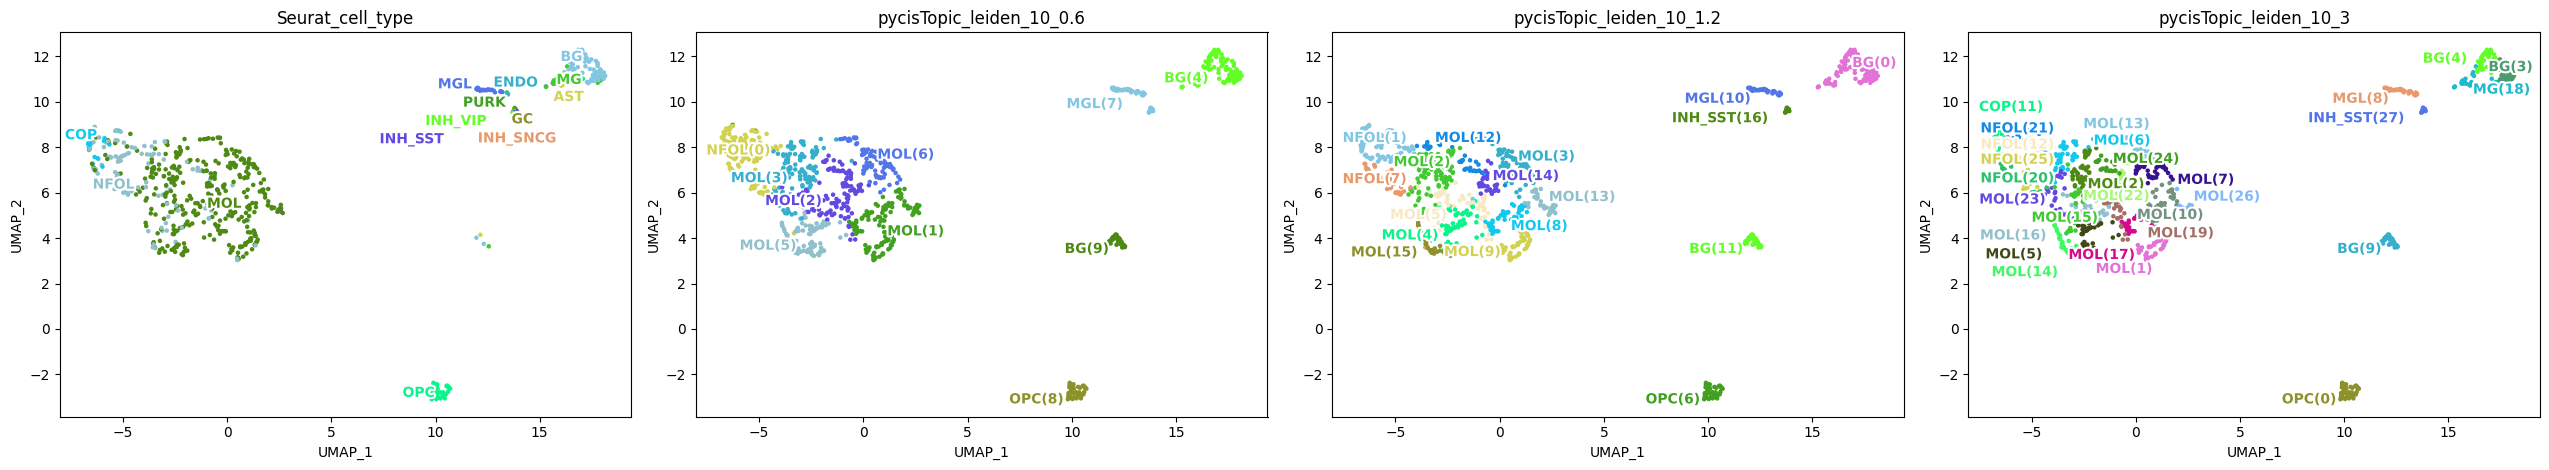

In [28]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['Seurat_cell_type', 'pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

We can also plot continuous values.

KeyError: 'Doublet_scores_fragments'

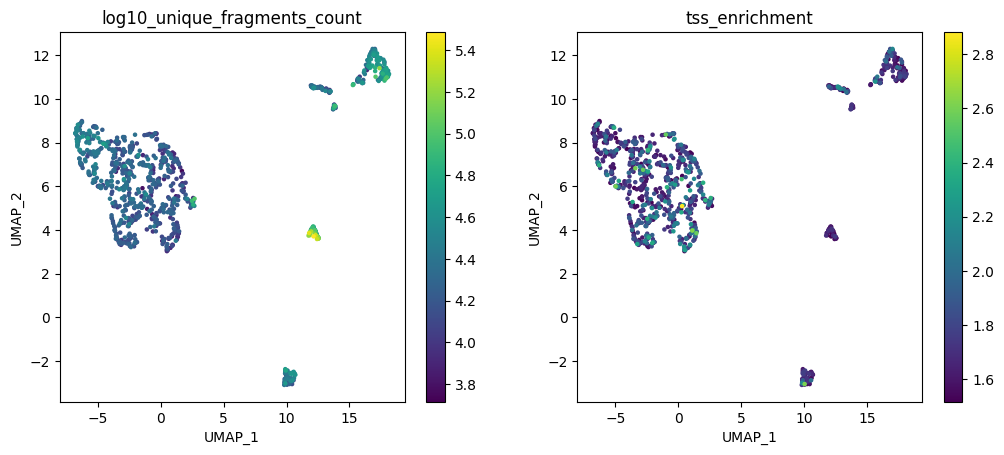

In [29]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['log10_unique_fragments_count', 'tss_enrichment', 'Doublet_scores_fragments', 'fraction_of_fragments_in_peaks'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

In [ ]:
Let's visualize cell-topic contributions.

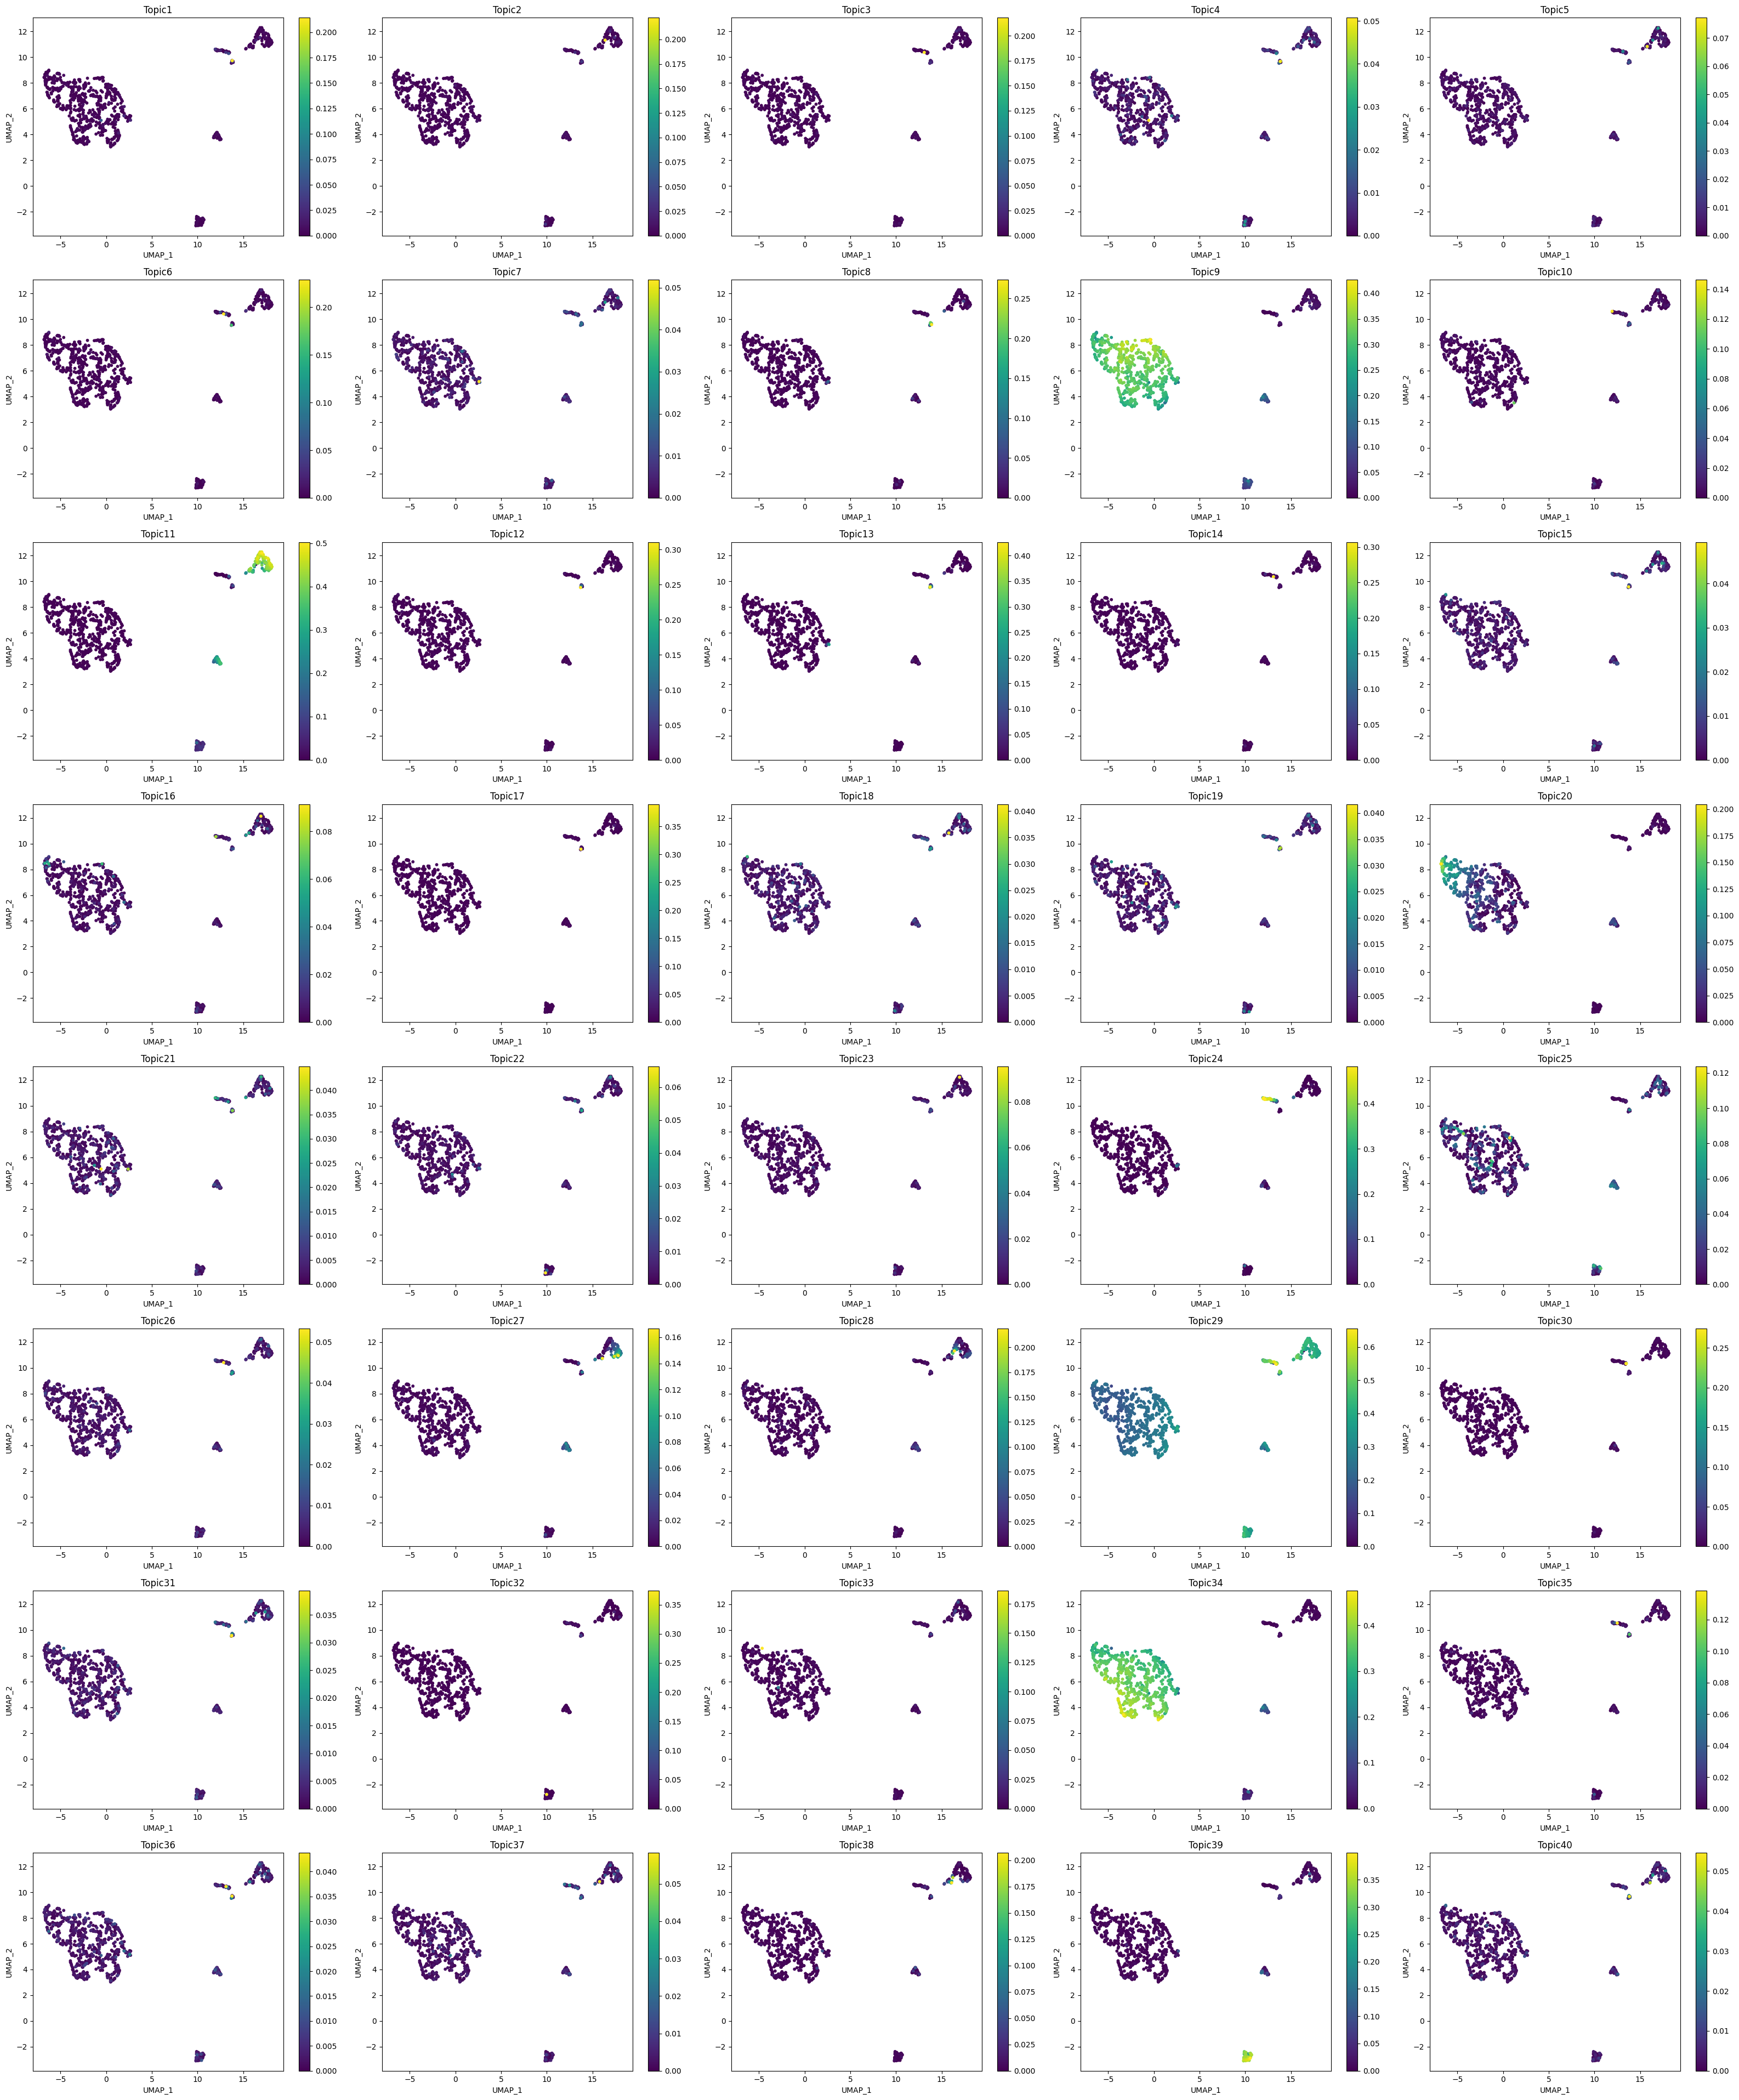

In [30]:
plot_topic(
    cistopic_obj,
    reduction_name = 'UMAP',
    target = 'cell',
    num_columns=5
)

In [ ]:
Or we can also draw a heatmap with the topic contributions (and annotations).

In [31]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['Seurat_cell_type'],
    scale = False,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10)
)

KeyError: "None of [Index(['GACCTAAGTTTGGCGG-1-10x_multiome_brain',\n       'GCTATTGCAACACCTA-1-10x_multiome_brain',\n       'ACATTGCAGTAGCCAT-1-10x_multiome_brain',\n       'TCAGCCTTCCTAGTCC-1-10x_multiome_brain',\n       'AGCGGACCAGCTTAGC-1-10x_multiome_brain',\n       'AGGTTTGGTTGTTGGA-1-10x_multiome_brain',\n       'CAGCTCAAGCAAACCT-1-10x_multiome_brain',\n       'CGTATTGCATCGCTTT-1-10x_multiome_brain',\n       'CAGGTCCAGTAACGGA-1-10x_multiome_brain',\n       'AGTTTGCAGCTATGAC-1-10x_multiome_brain',\n       ...\n       'GTCCAGGGTCAGGCCA-1-10x_multiome_brain',\n       'CTCATTGTCTTAGGGT-1-10x_multiome_brain',\n       'TCCAGCAAGCGCTCAA-1-10x_multiome_brain',\n       'CATCCTGGTTAGGATT-1-10x_multiome_brain',\n       'TGGATTGGTTAGGCTA-1-10x_multiome_brain',\n       'CCTCAATGTGTCCAAA-1-10x_multiome_brain',\n       'TGTCAATCAGGCTGTT-1-10x_multiome_brain',\n       'GCTTTACGTTGTGACA-1-10x_multiome_brain',\n       'TACTGGCCACCGGTAT-1-10x_multiome_brain',\n       'GGCTCACAGGCCCAGT-1-10x_multio

## Topic binarization & QC
Next we can binarize topic-region and cell-topic distributions. The first is useful for exploring the topics with other tools that work with region sets (e.g. GREAT, cisTarget); while the latter is useful to automatically annotate topics.

We will first binarize the topic-region distributions. There are several methods that can be used for this: ‘otsu’ (Otsu, 1979), ‘yen’ (Yen et al., 1995), ‘li’ (Li & Lee, 1993), ‘aucell’ (Van de Sande et al., 2020) or ‘ntop’ (Taking the top n regions per topic). Otsu and Yen’s methods work well for topic-region distributions; however for some downstream analyses (e.g. deep learning) it may be convenient to use ntop to have balanced region sets.



In [32]:
from pycisTopic.topic_binarization import binarize_topics

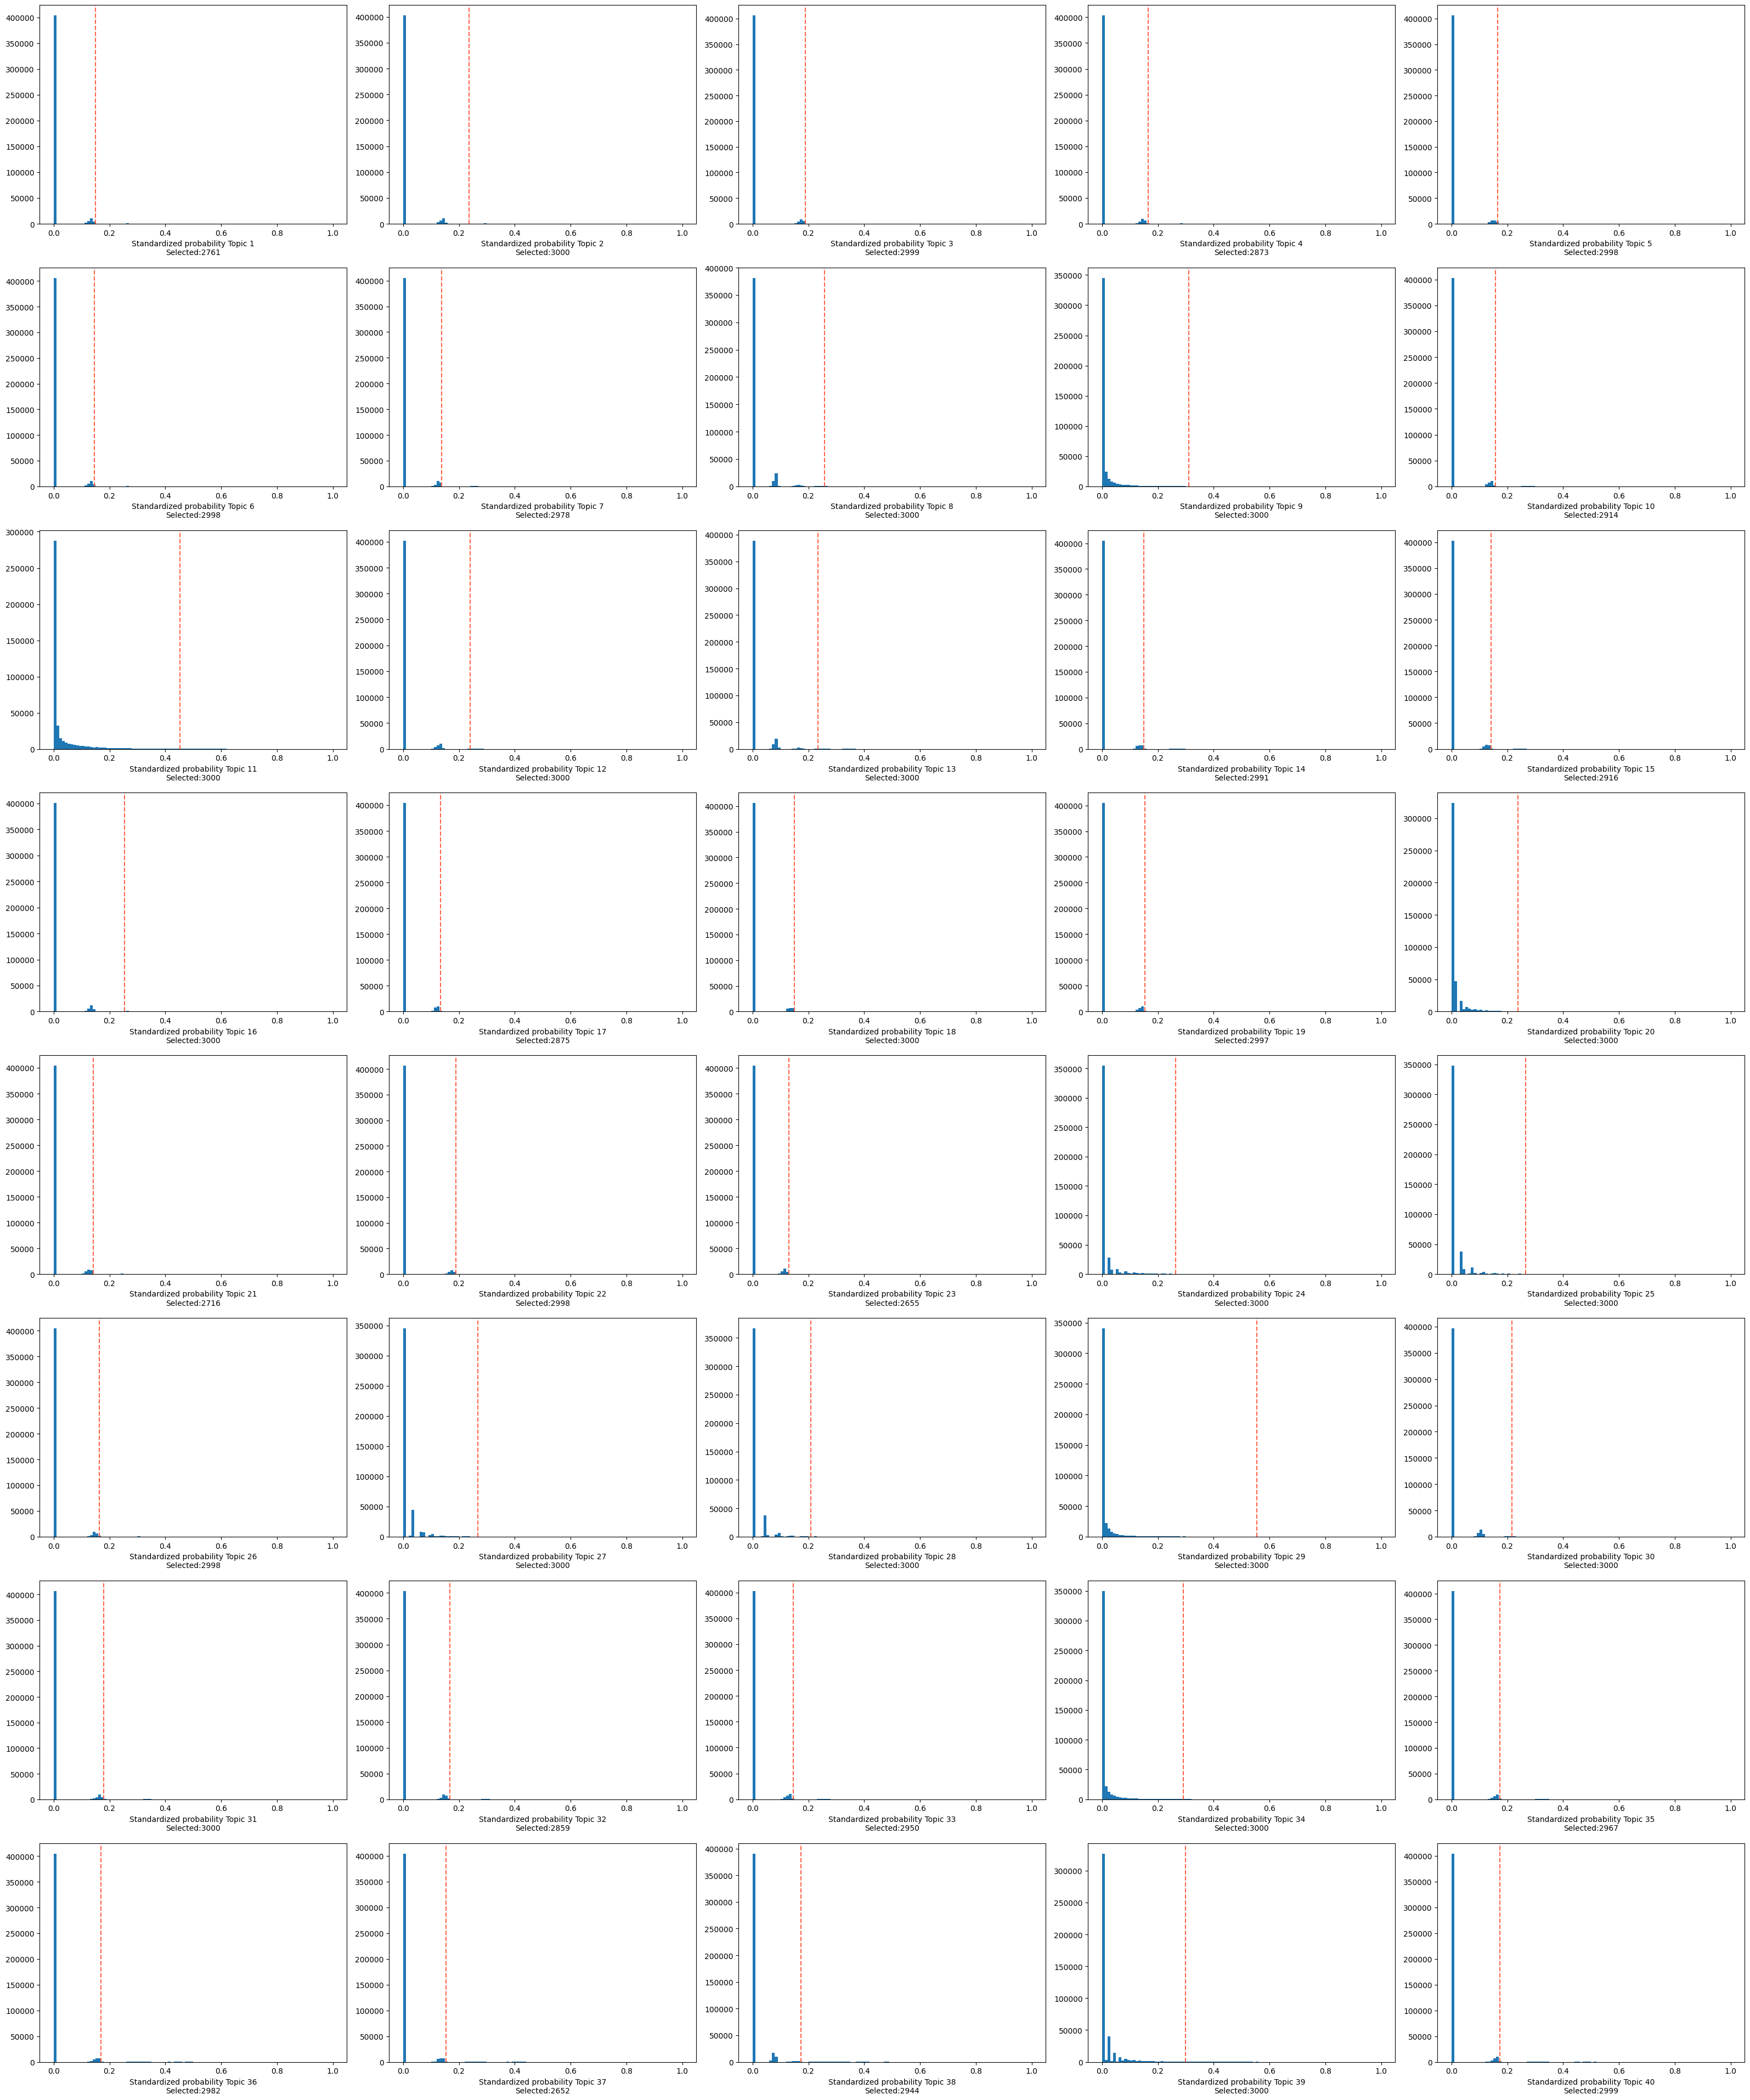

In [33]:
region_bin_topics_top_3k = binarize_topics(
    cistopic_obj, method='ntop', ntop = 3_000,
    plot=True, num_columns=5
)

In [ ]:
region_bin_topics_otsu = binarize_topics(
    cistopic_obj, method='otsu',
    plot=True, num_columns=5
)

Similarly, we can now binarize the cell-topic distribions.

In [ ]:
binarized_cell_topic = binarize_topics(
    cistopic_obj,
    target='cell',
    method='li',
    plot=True,
    num_columns=5, nbins=100)